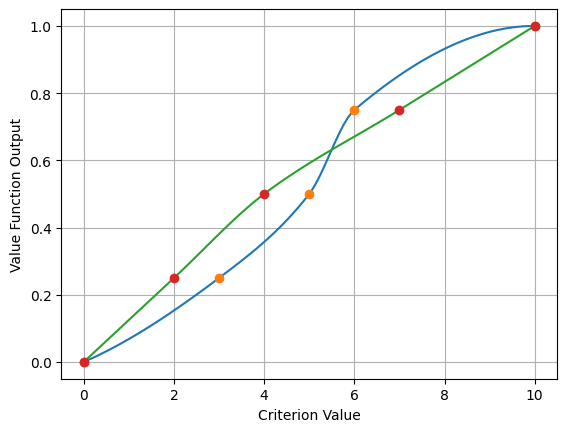

In [82]:
# Results of value function elicitation
C1_vf_a_points = [0, 3, 5, 6, 10]
C1_vf_b_points = [0, 2, 4, 7, 10]
C2_vf_a_points = [0, 4, 6, 8, 10]
C2_vf_b_points = [0, 3, 5, 7, 10]
C3_vf_a_points = [0, 2, 7, 9, 10]
C3_vf_b_points = [0, 1, 6, 8, 10]

elicitation_values = [0, 0.25, 0.5, 0.75, 1]

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator


def value_function(*points):
    x = np.linspace(0, 10, 100)
    value_functions = []
    for point in points:
        vf = PchipInterpolator(point, elicitation_values)
        value_functions.append(vf)
        plt.plot(x, vf(x))
        plt.plot(point, elicitation_values, "o")

    plt.xlabel("Criterion Value")
    plt.ylabel("Value Function Output")
    plt.grid()
    plt.show()
    return value_functions

vf_C1 = value_function(C1_vf_a_points, C1_vf_b_points)

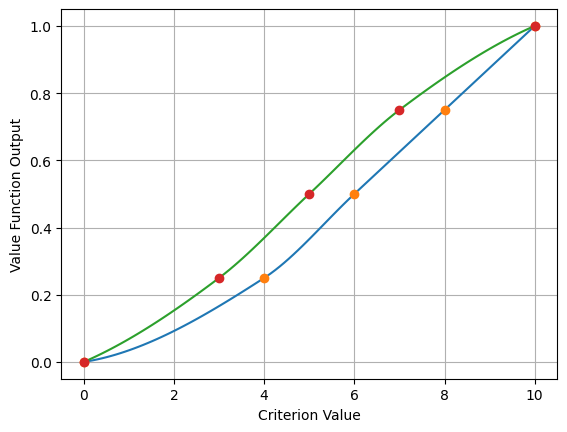

In [83]:
vf_C2 = value_function(C2_vf_a_points, C2_vf_b_points)


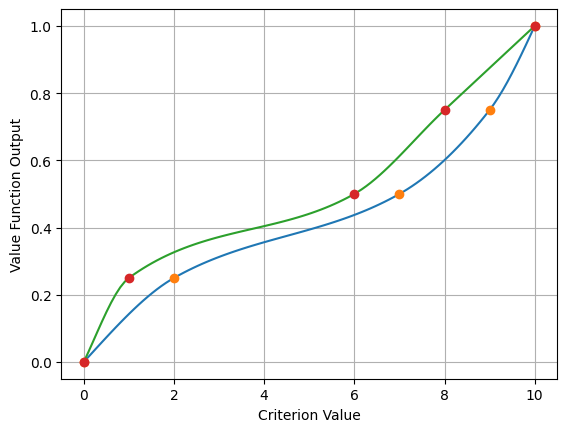

In [84]:
vf_C3 = value_function(C3_vf_a_points, C3_vf_b_points)


In [85]:
# Let's assume all criteria are between 0 and 10
criteria = ["C1", "C2", "C3"]

# One exact value, one Gaussian, one discrete set
alternative_A = [9,(7, 0.7),[8, 8, 7]]  # Criterion values for alternative A
alternative_B = [6,(6, 0.6),[7, 8, 6]]  # Criterion values for alternative B
alternative_C = [2,(3, 0.3),[9, 6, 8]]  # Criterion values for alternative C

vf_list = [vf_C1, vf_C2, vf_C3]
alternatives = [alternative_A, alternative_B, alternative_C]

In [86]:
from scipy.stats import norm, rv_discrete

# Input data distributions
def create_distributions(alternative):
    output = []
    for alt in alternative:
        if isinstance(alt, tuple):
            gaussian_dist = norm(loc=alt[0], scale=alt[1])
            output.append(gaussian_dist)

        elif isinstance(alt,list):
            unique_values = np.unique(alt)
            probabilities = np.array([np.sum(alt == val) for val in unique_values]) / len(alt)
            discrete_dist = rv_discrete(values=(unique_values, probabilities))
            output.append(discrete_dist)
        else:
            output.append(alt)

    return output

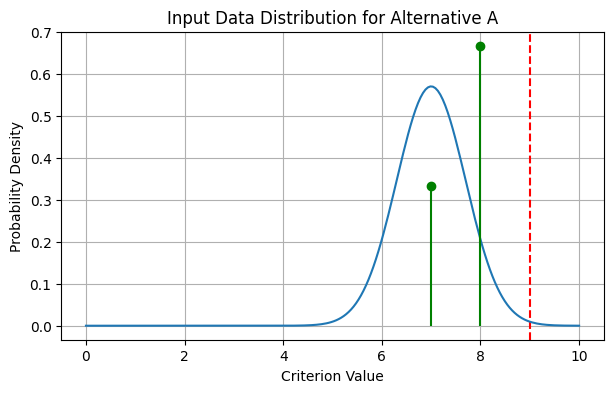

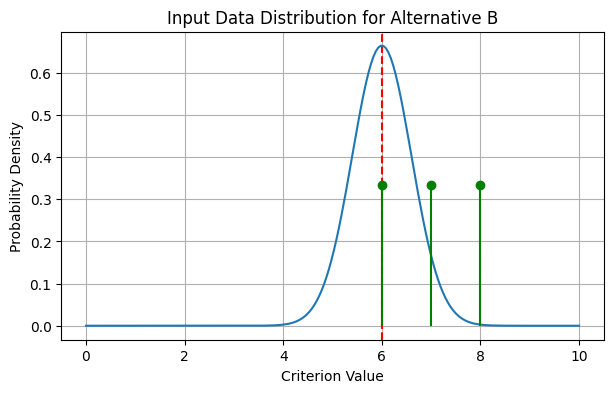

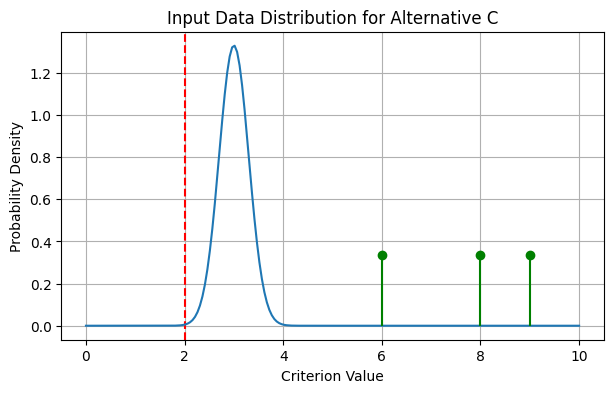

In [87]:
# Plot input data distributions
for i, alt in enumerate(alternatives):
    data_dist = create_distributions(alt)
    plt.figure(figsize=(7, 4))
    for dist in data_dist:
        if hasattr(dist, "rvs"):
            if hasattr(dist, "pdf"):
                x = np.linspace(0, 10, 200)
                y = dist.pdf(x)
                plt.plot(x, y)
            elif hasattr(dist, "pmf"):
                # Get the support of the discrete distribution
                x_discrete = dist.xk
                y_discrete = dist.pmf(x_discrete)
                plt.stem(x_discrete, y_discrete, linefmt='g-', markerfmt='go', basefmt=" ")
        else:
            plt.axvline(dist, color='r', linestyle='--')
    plt.xlabel("Criterion Value")
    plt.ylabel("Probability Density")
    plt.title(f"Input Data Distribution for Alternative {chr(65+i)}")
    plt.grid()
    plt.show()

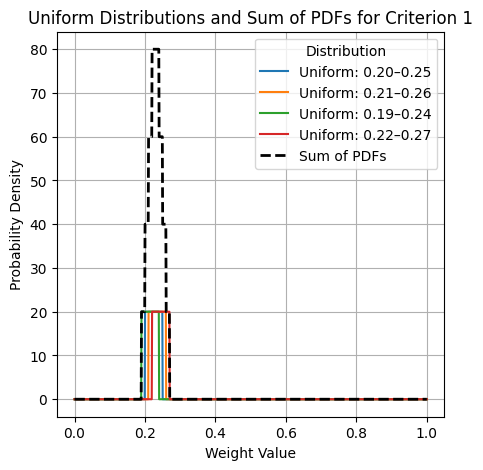

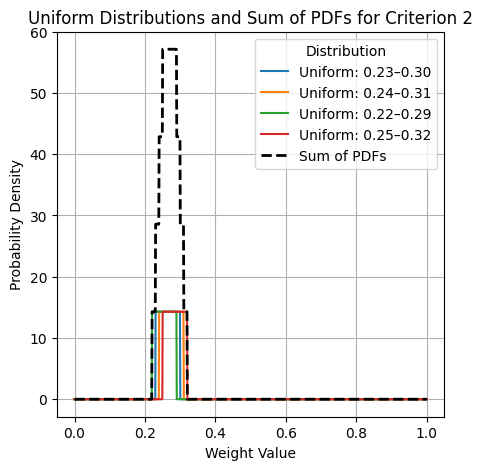

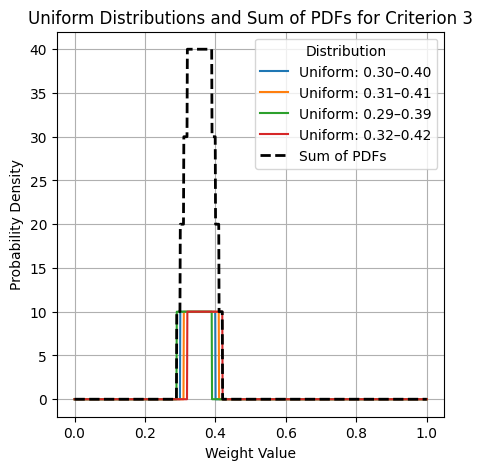

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Define the 3 weights, each with 4 possible uniform distributions (min, max pairs)
weights = [
    [(0.2, 0.25), (0.21, 0.26), (0.19, 0.24), (0.22, 0.27)],  # Criterion 1
    [(0.23, 0.3), (0.24, 0.31), (0.22, 0.29), (0.25, 0.32)],   # Criterion 2
    [(0.3, 0.4), (0.31, 0.41), (0.29, 0.39), (0.32, 0.42)]    # Criterion 3
]
criteria = ["Criterion 1", "Criterion 2", "Criterion 3"]

# Define x values for plotting (0 to 1)
x = np.linspace(0, 1, 1000)

# Create a list of lists of uniform distributions for each criterion
weight_distributions = []
for set_elicited_weights in weights:
    dist_list = []
    for weight_ranges in set_elicited_weights:
        dist_list.append(uniform(loc=weight_ranges[0], scale=weight_ranges[1] - weight_ranges[0]))
    weight_distributions.append(dist_list)

# Plot individual and summed PDFs for each criterion
for idx, dist_list in enumerate(weight_distributions):
    plt.figure(figsize=(5,5))

    # Plot individual uniform distributions
    for dist in dist_list:
        y = dist.pdf(x)
        loc = dist.kwds['loc']
        scale = dist.kwds['scale']
        plt.plot(x, y, label=f"Uniform: {loc:.2f}–{loc + scale:.2f}")

    # Sum the y-values (PDFs) of all 4 uniforms
    y_sum = np.zeros_like(x)
    for dist in dist_list:
        y_sum += dist.pdf(x)

    # Plot the sum of the PDFs
    plt.plot(x, y_sum, 'k--', linewidth=2, label="Sum of PDFs")

    plt.xlabel("Weight Value")
    plt.ylabel("Probability Density")
    plt.title(f"Uniform Distributions and Sum of PDFs for {criteria[idx]}")
    plt.legend(title="Distribution")
    plt.grid()
    plt.show()


$$
\text{PDF}_A(a) = \sum _i ^N \int _w \int _v \int_x \delta (a - v_i(x_i)w_i) \cdot \text{PDF}_X(x_i) \cdot \text{PDF}_V(v_i) \cdot \text{PDF}_W(w_i) dxdvdw
$$

## Fully numerical approach

In [89]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

bin_size = 100

# Criteria names
criteria = ["C1", "C2", "C3"]

# Define alternatives
alternative_A = [9, (7, 0.7), [8, 8, 7]]  # Criterion values for alternative A
alternative_B = [6, (6, 0.6), [7, 8, 6]]  # Criterion values for alternative B
alternative_C = [2, (3, 0.3), [9, 6, 8]]  # Criterion values for alternative C
alternatives = [alternative_A, alternative_B, alternative_C]


In [90]:
# Convert to values
def to_values(input_data, value_function):
    if isinstance(input_data, tuple):
        # Gaussian distribution
        mean, std_dev = input_data
        x = np.linspace(mean - 4*std_dev, mean + 4*std_dev, bin_size)
        pdf = norm.pdf(x, loc=mean, scale=std_dev)
        values = value_function(x)
        return x, pdf, values

    elif isinstance(input_data, list):
        # Discrete set
        unique_values, counts = np.unique(input_data, return_counts=True)
        probabilities = counts / len(input_data)
        values = value_function(unique_values)
        return unique_values, probabilities, values

    else:
        # Exact value
        value = value_function(input_data)
        return np.array([input_data]), np.array([1.0]), np.array([value])
    
# Apply to all alternatives and criteria
value_distributions = []
for alt in alternatives:
    alt_distributions = []
    for i, criterion_value in enumerate(alt):
        x, pdf, values = to_values(criterion_value, vf_list[i][0])  # Using the first elicited VF for simplicity
        alt_distributions.append((x, pdf, values))
    value_distributions.append(alt_distributions)

# # Plot value distributions for each alternative and criterion as histograms
# for alt_idx, alt_dists in enumerate(value_distributions):
#     for crit_idx, (x, pdf, values) in enumerate(alt_dists):
#         plt.figure(figsize=(7, 4))
#         if len(x) > 1:
#             plt.bar(values, pdf, width=0.05, alpha=0.7, color='b', align='center')
#         else:
#             plt.bar(values, pdf, width=0.1, alpha=0.7, color='b', align='center')
#         plt.xlabel("Value Function Output")
#         plt.ylabel("Probability Density")
#         plt.title(f"Value Distribution for Alternative {chr(65 + alt_idx)}, {criteria[crit_idx]}")
#         plt.grid()
#         plt.xlim(0, 1)
#         plt.show()

weights = [
    [(0.2, 0.25), (0.21, 0.26), (0.19, 0.24), (0.22, 0.27)],  # Criterion 1
    [(0.23, 0.3), (0.24, 0.31), (0.22, 0.29), (0.25, 0.32)],   # Criterion 2
    [(0.3, 0.4), (0.31, 0.41), (0.29, 0.39), (0.32, 0.42)]    # Criterion 3
]
# Compute overall distribution of weights by combining all uniform distributions
weight_distributions = []
for set_elicited_weights in weights:
    weight_array = np.zeros(bin_size)
    for weight_ranges in set_elicited_weights:
        minimum = weight_ranges[0]
        maximum = weight_ranges[1]
        # Find indices in the bins
        start_idx = int((minimum / 1.0) * bin_size)
        end_idx = int((maximum / 1.0) * bin_size)
        weight_array[start_idx:end_idx] += 1 / (maximum - minimum +1)
    weight_distributions.append(weight_array/np.sum(weight_array))

In [91]:
# Value sampling function
def sample_to_values(input_data, value_function):
    if isinstance(input_data, tuple):
        mean, std_dev = input_data
        sample = norm.rvs(loc=mean, scale=std_dev)
        value = value_function(sample)
        return value

    elif isinstance(input_data, list):
        # Discrete set
        unique_values, counts = np.unique(input_data, return_counts=True)
        probabilities = counts / len(input_data)
        chosen_value = np.random.choice(unique_values, p=probabilities)
        value = value_function(chosen_value)
        return value

    else:
        # Exact value
        value = value_function(input_data)
        return value

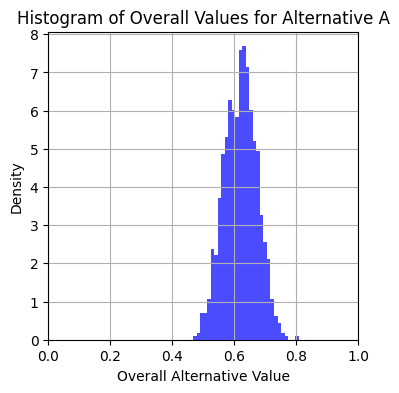

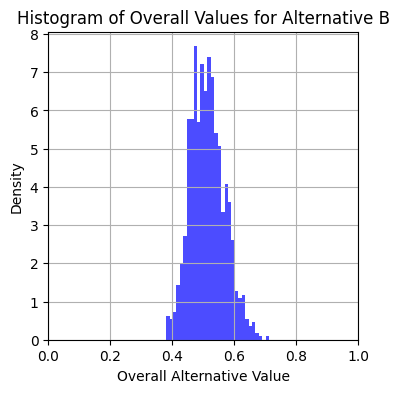

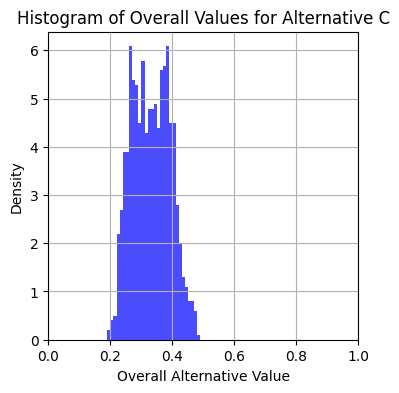

In [92]:


sim_runs = 1000
results = []
for _ in range(sim_runs):
    temp_results = []
    for a, alt in enumerate(alternatives):
        alternative_value = 0
        for c, criterion_data in enumerate(alt):

            #vf_list = [vf_C1, vf_C2, vf_C3]
            v_f = np.random.choice(vf_list[c]) # Sampling of value function, uniformly among elicited ones
            value = sample_to_values(criterion_data, v_f)

            # weight_distributions[c] is a probability array over bin_size bins in [0,1]
            weight_bins = np.linspace(0, 1, bin_size)
            probs = np.array(weight_distributions[c], dtype=float)
            chosen_idx = np.random.choice(len(weight_bins), p=probs)
            w = weight_bins[chosen_idx]
            res = w*value
            alternative_value += res
        temp_results.append(alternative_value)
    results.append(temp_results)   

# Plot histograms of overall alternative values
# each results[i] is a run and contains a value for each alternative
results = np.array(results)  # Shape: (sim_runs, num_alternatives)
num_alternatives = results.shape[1]
for alt_idx in range(num_alternatives):
    plt.figure(figsize=(4, 4))
    plt.hist(results[:, alt_idx], bins=30, density=True, alpha=0.7, color='b')
    plt.xlabel("Overall Alternative Value")
    plt.ylabel("Density")
    plt.title(f"Histogram of Overall Values for Alternative {chr(65 + alt_idx)}")
    plt.grid()
    plt.xlim(0, 1)
    plt.show()